# NOCT Thermal Uplift — Marginal Model Fit

Stage 1 (Modelling). Calibrates the seasonal daylight-temperature offset that
the production chain applies to every simulated daily temperature, and is the
sole producer of `noct_uplift_params.pkl`.

## Objective
The simulation produces a **daily mean** temperature, but module output responds
to cell temperature during **daylight hours**, which is both warmer than the
24-hour mean and warmest exactly when irradiance is highest. This notebook
measures that gap on the ERA5 hourly record and reduces it to a smooth seasonal
profile `uplift[doy]`.

Calibrating the offset on irradiance-weighted hourly data is what makes it
legitimate for the downstream notebooks to apply `f_temp` to a **daily**
irradiance total rather than convolving hour by hour. Without this step the
production chain would systematically understate thermal derating in summer,
when the daylight/24-hour gap is widest.

**Method** — physics-based, no regression:

| step | formula |
|---|---|
| hourly cell temperature | `T_cell(h) = T_amb(h) + (NOCT - 20)/800 * GHI(h)` |
| daily effective temperature | `T_eff_daily = GHI-weighted mean of T_cell over hours with GHI > 0` |
| seasonal offset | `uplift[doy] = periodic spline through 12 monthly means of (T_eff_daily - T_mean_24h)` |

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Data/Cleaned/df_bologna_cleaned.parquet` (ERA5 hourly `t2m`, `GHI`) | Hourly cell temperature -> GHI-weighted daily mean -> monthly anchors -> periodic cubic spline | `Code/Models/Temperature/noct_uplift_params.pkl` |

## Decision Log

| # | Decision | Alternatives | Rationale | Impact |
|---|---|---|---|---|
| D1 | NOCT form `(NOCT - 20)/800`, with `NOCT = 45 °C` | Faiman model using ERA5 wind | The NOCT form assumes a fixed 1 m/s wind and is wind-independent; a Faiman model would fit better but needs a wind coefficient this repository has not fitted | Small, seasonal bias in the uplift; the sign of the seasonal shape is unaffected |
| D2 | Weight the daily mean by GHI, over daylight hours only | Unweighted daylight mean, or the plain 24-hour mean | Output is proportional to irradiance, so the temperature that matters is the one realised when irradiance is high. An unweighted mean would under-weight midday and understate the uplift | This is the whole point of the notebook: the weighted/24-hour gap is the quantity being measured |
| D3 | Monthly means as spline anchors, not day-of-year means | Spline through 366 day-of-year means | Each monthly anchor rests on roughly 600 observations against roughly 20 per individual day-of-year, so the monthly profile is far less noisy | The profile is smooth by construction; genuine sub-monthly structure, if any, is not recoverable |
| D4 | Periodic cubic spline (`bc_type="periodic"`) | Not-a-knot spline on wrapped anchors | The profile must close on itself at the year boundary and match its first derivative across 31 Dec -> 1 Jan, which not-a-knot does not guarantee | Asserted below: the year-boundary gap must be under 1 °C |
| D5 | `MAX_UPLIFT = 40 °C` clip, applied as a clip and **not** as a drop | Drop days above the threshold | Clipping keeps the day in its day-of-year average. Dropping would remove only that day-of-year's hot outliers and so bias its average upward — the opposite of the intended correction | A handful of days per record; reported explicitly below |
| D6 | Day-of-year used as the seasonal key, with no leap-year correction | Map to a fractional year position | In non-leap years every date after 28 Feb maps to the doy of the following calendar date in a leap year | Under 0.1 °C given the smoothness of the profile; not corrected for |

## Setup

In [1]:
import calendar
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

sys.path.append(str(Path("..").resolve()))
from model_utils import find_project_root, NOCT

In [2]:
# -- paths --------------------------------------------------------------------
ROOT = find_project_root()
data_cleaned = ROOT / "Data" / "Cleaned"
models_temp = ROOT / "Code" / "Models" / "Temperature"
models_temp.mkdir(parents=True, exist_ok=True)

# NOCT is the only production-chain constant this notebook needs; it is imported
# from model_utils so the calibration and the chain that consumes it cannot
# disagree about the module technology.
NOCT_COEFF = (NOCT - 20) / 800   # degC per W/m2

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("-- Configuration -----------------------------------------------")
print(f"  NOCT       = {NOCT} C")
print(f"  heat coeff = {NOCT_COEFF:.5f} C*m2/W   (D1)")
print(f"  input      : {data_cleaned / 'df_bologna_cleaned.parquet'}")
print(f"  output     : {models_temp / 'noct_uplift_params.pkl'}")

-- Configuration -----------------------------------------------
  NOCT       = 45.0 C
  heat coeff = 0.03125 C*m2/W   (D1)
  input      : C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Cleaned\df_bologna_cleaned.parquet
  output     : C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Code\Models\Temperature\noct_uplift_params.pkl


### Hourly cell temperature from ERA5

In [3]:
print("── Thermal uplift: hourly cell temperature ──────────────────────")

# ── load ERA5 hourly data ─────────────────────────────────────────────────────
# Data/Cleaned/df_bologna_cleaned.parquet is a Stage-0 (Transformation) output;
# the orchestrator (Code/pipeline.ipynb) guarantees it lives there, so no
# fallback search is needed.
era5_path = data_cleaned / "df_bologna_cleaned.parquet"
df_era5 = pd.read_parquet(era5_path)
df_era5["datetime"] = pd.to_datetime(df_era5["time"])
df_era5["date_only"] = df_era5["datetime"].dt.date

# confirm temperature in °C
if df_era5["t2m"].mean() > 100:
    df_era5["t2m"] = df_era5["t2m"] - 273.15
    print("  t2m converted from K to °C")

print(f"  ERA5 loaded : {len(df_era5):,} rows")
print(f"  Date range  : {df_era5['datetime'].min().date()} → "
      f"{df_era5['datetime'].max().date()}")
print(f"  t2m mean    : {df_era5['t2m'].mean():.2f}°C")
print(f"  GHI mean    : {df_era5['GHI'].mean():.1f} W/m²")

# ── data integrity: every calendar day must carry 24 hourly observations ──────
_hours_per_day = df_era5.groupby("date_only").size()
_short_days = _hours_per_day[_hours_per_day != 24]
if len(_short_days) > 0:
    print(f"  ! {len(_short_days)} day(s) do not have 24 hourly rows — their "
          f"24h mean is taken over fewer hours:")
    for _d, _n in _short_days.head(5).items():
        print(f"      {_d}: {_n} rows")
    if len(_short_days) > 5:
        print(f"      ... and {len(_short_days)-5} more")
assert len(_short_days) / _hours_per_day.size < 0.01, (
    f"STOP — {len(_short_days)} of {_hours_per_day.size} days have incomplete "
    f"hourly coverage (>1%). Check the ERA5 extraction."
)

# D1: NOCT hourly cell-temperature model, (NOCT-20)/800 -- physics-based, no regression.
NOCT_COEFF = (NOCT - 20) / 800   # °C per W/m²
df_era5["T_cell"] = df_era5["t2m"] + NOCT_COEFF * df_era5["GHI"]

# ── 24-hour daily mean T (all hours — before GHI filter) ─────────────────────
T_mean_24h = (
    df_era5.groupby("date_only")["t2m"]
    .mean()
    .rename("T_mean_24h")
)

# D2: GHI-weighted mean over daylight hours only -- output is proportional to
# irradiance, so the temperature that matters is the one realised when
# irradiance is high.
# vectorised weighted mean: sum(w·x) / sum(w) over each day
df_day = df_era5[df_era5["GHI"] > 0].copy()
print(f"  Daylight rows: {len(df_day):,}  "
      f"({len(df_day)/len(df_era5)*100:.1f}%)")

_num = (df_day["GHI"] * df_day["T_cell"]).groupby(df_day["date_only"]).sum()
_den = df_day["GHI"].groupby(df_day["date_only"]).sum()
T_eff_daily = (_num / _den).rename("T_eff_daily")

# ── daily uplift ──────────────────────────────────────────────────────────────
uplift_df = pd.DataFrame({
    "T_eff_daily": T_eff_daily,
    "T_mean_24h":  T_mean_24h,
}).dropna()
uplift_df["uplift"] = uplift_df["T_eff_daily"] - uplift_df["T_mean_24h"]
uplift_df.index     = pd.to_datetime(uplift_df.index)
# D6: day-of-year is the seasonal key, with no leap-year correction.
uplift_df["doy"]    = uplift_df.index.dayofyear

# D5: clip, do not drop, physically implausible uplift.
# Clipping keeps the day in the seasonal average; dropping it would silently
# bias the affected day-of-year upward by removing only its hot outliers.
MAX_UPLIFT = 40.0
n_clipped  = int((uplift_df["uplift"] > MAX_UPLIFT).sum())
uplift_df["uplift"] = uplift_df["uplift"].clip(upper=MAX_UPLIFT)
print(f"  Clipped {n_clipped} day(s) with uplift > {MAX_UPLIFT}°C")

print(f"  Daily uplift: mean={uplift_df['uplift'].mean():.2f}°C  "
      f"min={uplift_df['uplift'].min():.2f}°C  "
      f"max={uplift_df['uplift'].max():.2f}°C")

── Thermal uplift: hourly cell temperature ──────────────────────


  ERA5 loaded : 184,079 rows
  Date range  : 2005-01-01 → 2025-12-31
  t2m mean    : 13.30°C
  GHI mean    : 170.2 W/m²
  ! 1 day(s) do not have 24 hourly rows — their 24h mean is taken over fewer hours:
      2005-01-01: 23 rows
  Daylight rows: 100,027  (54.3%)


  Clipped 0 day(s) with uplift > 40.0°C
  Daily uplift: mean=16.04°C  min=0.75°C  max=27.83°C


### Seasonal uplift profile

In [4]:
# D3: monthly means, not day-of-year means, as spline anchors.
# Monthly means are the anchors because they rest on ~600 observations each,
# against ~20 per individual day-of-year.
print("── Thermal uplift: seasonal profile ─────────────────────────────")

uplift_df["month"] = uplift_df.index.month
monthly_mean = uplift_df.groupby("month")["uplift"].mean()

# representative doy for each month midpoint
month_midday = {1: 16, 2: 45, 3: 75, 4: 105, 5: 136, 6: 166,
                7: 197, 8: 228, 9: 258, 10: 289, 11: 319, 12: 350}

anchor_doys    = np.array([month_midday[m] for m in sorted(monthly_mean.index)])
anchor_uplifts = np.array([monthly_mean[m] for m in sorted(monthly_mean.index)])

# D4: periodic spline, so the profile closes on itself at the year boundary.
# CubicSpline(bc_type="periodic") requires y[0] == y[-1], so the December
# anchor is repeated one year later to close the loop. This matches the
# first derivative across 31 Dec → 1 Jan, which "not-a-knot" on wrapped
# anchors does not.
doys_periodic    = np.concatenate([anchor_doys, anchor_doys[:1] + 365])
uplifts_periodic = np.concatenate([anchor_uplifts, anchor_uplifts[:1]])
cs = CubicSpline(doys_periodic, uplifts_periodic, bc_type="periodic")

# evaluate over the full year, wrapping doys below the first anchor
doys_full     = np.arange(1, 367)
uplift_smooth = cs(np.where(doys_full < anchor_doys[0],
                            doys_full + 365, doys_full))

uplift_by_doy = {int(d): float(v) for d, v in zip(doys_full, uplift_smooth)}

# NOTE: day-of-year is used as the seasonal key, so in non-leap years every
# date after 28 Feb maps to the doy of the following calendar date in a leap
# year. The resulting offset is under 0.1°C given the smoothness of the
# profile and is not corrected for.

print(f"  DOY entries  : {len(uplift_by_doy)}")
print(f"  Annual mean  : {np.mean(list(uplift_by_doy.values())):.2f}°C")
print(f"  Min (doy)    : {min(uplift_by_doy.values()):.2f}°C  "
      f"doy={min(uplift_by_doy, key=uplift_by_doy.get)}")
print(f"  Max (doy)    : {max(uplift_by_doy.values()):.2f}°C  "
      f"doy={max(uplift_by_doy, key=uplift_by_doy.get)}")
print(f"  Summer (JJA) : "
      f"{np.mean([uplift_by_doy[d] for d in range(172, 265)]):.2f}°C")
print(f"  Winter (DJF) : "
      f"{np.mean([uplift_by_doy[d] for d in list(range(1, 60)) + list(range(335, 367))]):.2f}°C")

# ── profile sanity checks (these can actually fail) ───────────────────────────
_jja = np.mean([uplift_by_doy[d] for d in range(172, 265)])
_djf = np.mean([uplift_by_doy[d]
                for d in list(range(1, 60)) + list(range(335, 367))])
assert _jja > _djf, (
    f"STOP — summer uplift ({_jja:.2f}°C) is not above winter "
    f"({_djf:.2f}°C); the seasonal profile is inverted."
)
assert min(uplift_by_doy.values()) > 0, (
    "STOP — uplift must be strictly positive: daylight cell temperature "
    "cannot fall below the 24-hour ambient mean."
)
_endpoint_gap = abs(uplift_by_doy[366] - uplift_by_doy[1])
assert _endpoint_gap < 1.0, (
    f"STOP — profile does not close at the year boundary "
    f"(gap {_endpoint_gap:.2f}°C)."
)
print(f"  Seasonality  : JJA {_jja:.2f}°C > DJF {_djf:.2f}°C  ✓")
print(f"  Year-boundary gap: {_endpoint_gap:.3f}°C  ✓ periodic")

── Thermal uplift: seasonal profile ─────────────────────────────
  DOY entries  : 366
  Annual mean  : 16.02°C
  Min (doy)    : 8.72°C  doy=355
  Max (doy)    : 22.71°C  doy=195
  Summer (JJA) : 21.15°C
  Winter (DJF) : 10.13°C
  Seasonality  : JJA 21.15°C > DJF 10.13°C  ✓
  Year-boundary gap: 0.000°C  ✓ periodic


### Diagnostics

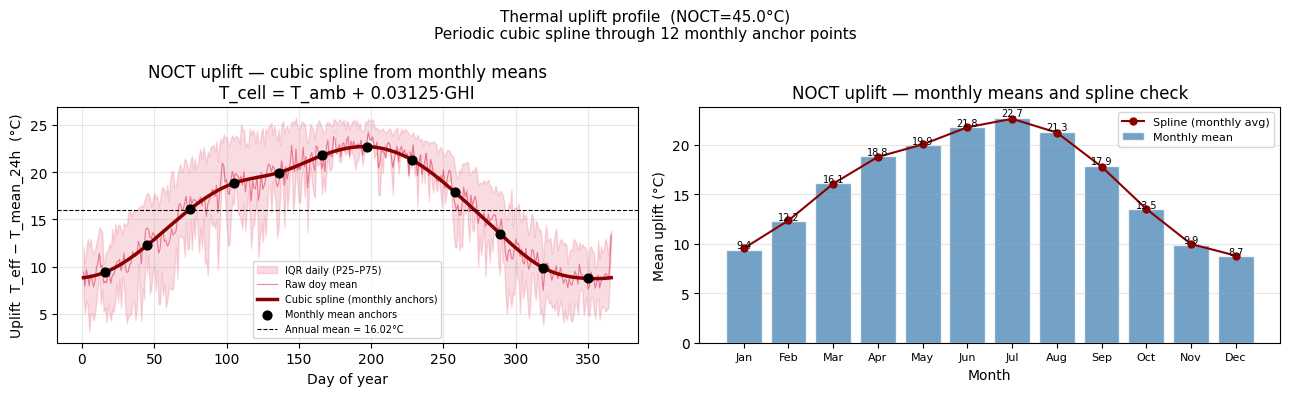

In [5]:
# ── updated plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: raw doy mean + smooth interpolated curve
ax = axes[0]
doys_raw  = np.array(sorted(
    uplift_df.groupby("doy")["uplift"].mean().to_dict().keys()
))
mean_raw  = np.array([
    uplift_df.groupby("doy")["uplift"].mean().to_dict()[d] for d in doys_raw
])
p25_raw   = uplift_df.groupby("doy")["uplift"].quantile(0.25).reindex(doys_raw).values
p75_raw   = uplift_df.groupby("doy")["uplift"].quantile(0.75).reindex(doys_raw).values

ax.fill_between(doys_raw, p25_raw, p75_raw,
                alpha=0.15, color="crimson", label="IQR daily (P25–P75)")
ax.plot(doys_raw, mean_raw,
        color="crimson", lw=0.8, alpha=0.5, label="Raw doy mean")
ax.plot(doys_full, uplift_smooth,
        color="darkred", lw=2.5, label="Cubic spline (monthly anchors)")
ax.scatter(anchor_doys, anchor_uplifts,
           color="black", s=40, zorder=5, label="Monthly mean anchors")
ax.axhline(np.mean(uplift_smooth), color="black", lw=0.8, ls="--",
           label=f"Annual mean = {np.mean(uplift_smooth):.2f}°C")
ax.set_xlabel("Day of year")
ax.set_ylabel("Uplift  T_eff − T_mean_24h  (°C)")
ax.set_title(f"NOCT uplift — cubic spline from monthly means\n"
             f"T_cell = T_amb + {NOCT_COEFF:.5f}·GHI")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# right: monthly bar chart with spline overlay
ax = axes[1]
bars = ax.bar(sorted(monthly_mean.index), monthly_mean.values,
              color="steelblue", alpha=0.75, edgecolor="white",
              label="Monthly mean")

# overlay spline as monthly mean from interpolated curve
# monthly average from interpolated spline

spline_monthly = {}
for m in range(1, 13):
    # get all doys belonging to this month in a non-leap year
    start_doy = sum(calendar.monthrange(2023, mm)[1] for mm in range(1, m)) + 1
    end_doy   = start_doy + calendar.monthrange(2023, m)[1]
    month_doys = [d for d in doys_full if start_doy <= d < end_doy]
    spline_monthly[m] = float(np.mean([uplift_by_doy[d] for d in month_doys]))
ax.plot(list(spline_monthly.keys()),
        list(spline_monthly.values()),
        "o-", color="darkred", lw=1.5, ms=5, label="Spline (monthly avg)")

ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Mean uplift (°C)")
ax.set_title("NOCT uplift — monthly means and spline check")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")
for bar, val in zip(bars, monthly_mean.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.15,
            f"{val:.1f}", ha="center", fontsize=7)

plt.suptitle(f"Thermal uplift profile  (NOCT={NOCT}°C)\n"
             f"Periodic cubic spline through 12 monthly anchor points",
             fontsize=11)
plt.tight_layout()
plt.show()

> **Takeaway.** The uplift is strongly seasonal, and both terms that drive it —
> the daylight/24-hour temperature gap and the irradiance weighting — peak in
> summer. A single annual constant would therefore understate derating in
> exactly the months that carry most of the annual yield, which is why the
> profile is indexed by day-of-year rather than averaged.

### Export

In [6]:
# -- save the profile ---------------------------------------------------------
# uplift_by_doy is the contract: every downstream reader takes this key and
# nothing else. The remaining entries are provenance, so a stale pickle can be
# recognised without re-running the fit.
out_path = models_temp / "noct_uplift_params.pkl"

noct_params = {
    "uplift_by_doy": uplift_by_doy,
    "NOCT": float(NOCT),
    "NOCT_COEFF": float(NOCT_COEFF),
    "MAX_UPLIFT": float(MAX_UPLIFT),
    "n_clipped": int(n_clipped),
    "monthly_mean": {int(m): float(v) for m, v in monthly_mean.items()},
    "anchor_doys": anchor_doys.tolist(),
    "calibration_start": str(uplift_df.index.min().date()),
    "calibration_end": str(uplift_df.index.max().date()),
    "n_days_calibration": int(len(uplift_df)),
}

with open(out_path, "wb") as f:
    pickle.dump(noct_params, f)

print("-- Export ------------------------------------------------------")
print(f"  Saved  : {out_path}")
print(f"  Size   : {out_path.stat().st_size / 1e3:.1f} kB")
print(f"  Keys   : {list(noct_params)}")
print(f"  Window : {noct_params['calibration_start']} -> "
      f"{noct_params['calibration_end']}  "
      f"({noct_params['n_days_calibration']:,} days)")

# -- read-back check ----------------------------------------------------------
# The artifact, not the in-memory dict, is what four downstream notebooks
# consume, so verify what actually landed on disk.
with open(out_path, "rb") as f:
    _check = pickle.load(f)
assert _check["uplift_by_doy"] == uplift_by_doy, (
    "STOP - the profile read back from the pickle does not match the one "
    "just computed."
)
assert len(_check["uplift_by_doy"]) == 366, (
    f"STOP - profile has {len(_check['uplift_by_doy'])} entries, expected 366 "
    f"(one per day-of-year including 29 Feb)."
)
print(f"  Read-back: {len(_check['uplift_by_doy'])} doy entries  OK")

-- Export ------------------------------------------------------
  Saved  : C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Code\Models\Temperature\noct_uplift_params.pkl
  Size   : 4.5 kB
  Keys   : ['uplift_by_doy', 'NOCT', 'NOCT_COEFF', 'MAX_UPLIFT', 'n_clipped', 'monthly_mean', 'anchor_doys', 'calibration_start', 'calibration_end', 'n_days_calibration']
  Window : 2005-01-01 -> 2025-12-31  (7,670 days)
  Read-back: 366 doy entries  OK


## Conclusion & Handoff

- The daylight cell-temperature uplift is seasonal and strictly positive, and
  the three profile assertions above (summer above winter, strictly positive,
  closes at the year boundary) are the conditions the downstream production
  chain depends on.
- It is calibrated on irradiance-weighted hourly ERA5 data (D2) and reduced to a
  periodic spline through twelve monthly anchors (D3, D4), so it is smooth
  enough to index by day-of-year.

**Next notebooks can rely on:**
`Code/Models/Temperature/noct_uplift_params.pkl` — key `uplift_by_doy`, a
`{1..366: °C}` dict, read by `Code/Simulation/02_variables_reconstruction.ipynb`,
`03_revenue_index_historical.ipynb`, `04_revenue_index_scenarios.ipynb` and
`05_hedge_contract.ipynb`. The profile is deterministic and identical across all
simulation paths: every stochastic component of `T_eff` comes from the
temperature paths, none from the uplift.